In [1]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install seaborn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings('ignore')


In [4]:
#df = pd.read_csv(r'D:\Amit Diploma\AMIT\Sources\DS\courses\titanic.csv')
#or change slashes 
#df = pd.read_csv('D:/Amit Diploma/AMIT/Sources/DS/courses/titanic.csv')


In [5]:
df = pd.read_csv('titanic.csv')

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
#id , ticket not imp
df.drop(['PassengerId','Name' ,'Ticket'], axis=1 , inplace=True)

In [8]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [9]:
df.dtypes

Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin        object
Embarked     object
dtype: object

In [10]:
'''dtypes = df.dtypes
n_uniq = df.nunique()
pd.DataFrame({'Dtypes': dtypes, 'Num_unique' : n_uniq})
pd.DataFrame({'Dtypes': dtypes, 'Num_unique' : n_uniq}).T'''

"dtypes = df.dtypes\nn_uniq = df.nunique()\npd.DataFrame({'Dtypes': dtypes, 'Num_unique' : n_uniq})\npd.DataFrame({'Dtypes': dtypes, 'Num_unique' : n_uniq}).T"

OR put this in a library

In [11]:
from my_preprocessing import dtype_func
dtype_func(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes,int64,int64,object,float64,int64,int64,float64,object,object
Num_unique,2,3,2,88,7,7,248,147,3


Survived , Pclass , Sex , Embarked , SibSp , Parch---> not numerical --> category
small num --> category 
big num --> numerical

In [12]:
cols = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch','Embarked']
df[cols] = df[cols].astype('category')
df.dtypes

Survived    category
Pclass      category
Sex         category
Age          float64
SibSp       category
Parch       category
Fare         float64
Cabin         object
Embarked    category
dtype: object

In [13]:
#null = df.isnull()
#null

In [14]:
null = df.isnull().sum()
null

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [15]:
'''null = df.isnull().sum()
ratio = (null/df.shape[0])*100 
pd.DataFrame({'Null_Sum': null, 'Ratio': ratio}).T'''

"null = df.isnull().sum()\nratio = (null/df.shape[0])*100 \npd.DataFrame({'Null_Sum': null, 'Ratio': ratio}).T"

or put it into function

In [16]:
from my_preprocessing import null_sum
null_sum(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Null_Sum,0.0,0.0,0.0,177.00000,0.0,0.0,0.0,687.000000,2.000000
Ratio,0.0,0.0,0.0,19.86532,0.0,0.0,0.0,77.104377,0.224467


if small number of Nulls --> drop them 
if not --> replace them by mean or median ( if we have outliers )
if huge --> drop col

In [17]:
#df = df.dropna(subset=['Embarked'], inplace = True)
#df = pd.read_csv('titanic.csv')

In [18]:
#df = df.drop('Cabin' , axis = 1 , inplace = True)
#df = pd.read_csv('titanic.csv')

In [19]:
df1 = df.dropna(subset=["Embarked"], inplace= True)
df.head()
df2 = df.drop("Cabin", axis=1, inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [20]:
median = df['Age'].median()
median
df['Age'].fillna(median, inplace = True)

In [21]:
df.Age

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 889, dtype: float64

In [22]:
#check outliers
num_cols = df.select_dtypes('number').columns
num_cols

Index(['Age', 'Fare'], dtype='object')

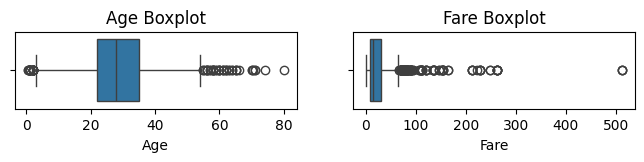

In [23]:
plt.figure(figsize = (8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col], orient='h')
    plt.title(f'{col} Boxplot')

In [24]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5*IQR
    upper_fence = Q3 + 1.5*IQR 

    lower_outliers = df[df[col] < lower_fence][col].values
    upper_outliers = df[df[col] > upper_fence][col].values

    df[col].replace(lower_outliers, lower_fence, inplace = True)
    df[col].replace(upper_outliers, upper_fence, inplace = True)

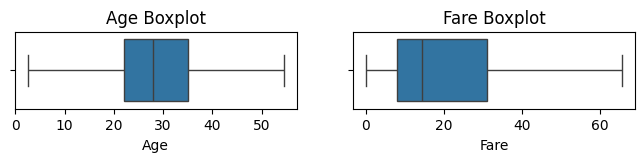

In [25]:
plt.figure(figsize = (8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col], orient='h')
    plt.title(f'{col} Boxplot')

Histogram & KDE plt for numercial cols

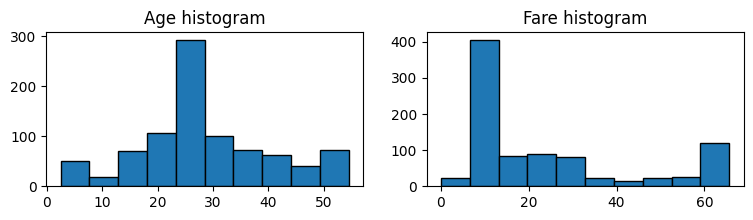

In [26]:
plt.figure(figsize = (9,2))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    plt.hist(df[col], edgecolor='black')
    plt.title(f'{col} histogram')

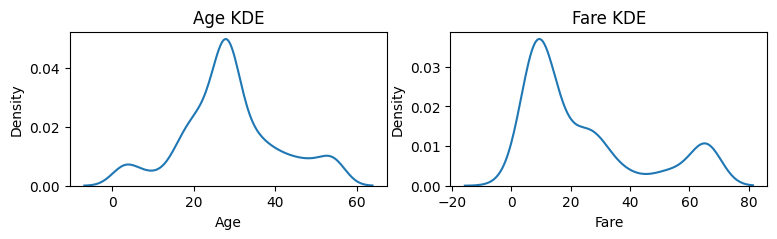

In [27]:
plt.figure(figsize = (9,2))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.kdeplot(df[col])
    plt.title(f'{col} KDE')